Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


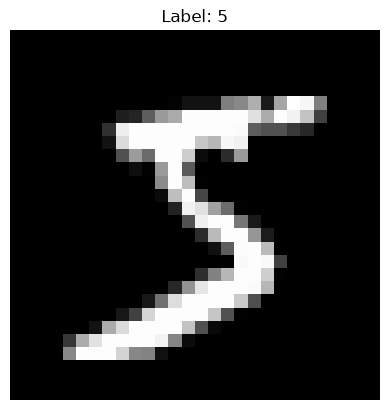

In [6]:
# importing libraries and dataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

#exploring the dataset
print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

#displaying the first image in the training dataset
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [7]:
#displaying model summary
model.summary()

model.save("cnn_mnist.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

In [ ]:
#in this block we are preprocessing the data and basically constructing the model

# normalizing the values of the pixels to be between 0 and 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation="relu"), #using ReLu complex patterns can be learned
    layers.MaxPooling2D((2,2)),  #reducing the img size 
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [4]:
#compiling the model and training it

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

#evaluating the model

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9494 - loss: 0.1633 - val_accuracy: 0.9825 - val_loss: 0.0593
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9836 - loss: 0.0534 - val_accuracy: 0.9846 - val_loss: 0.0535
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9888 - loss: 0.0355 - val_accuracy: 0.9862 - val_loss: 0.0481
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9912 - loss: 0.0265 - val_accuracy: 0.9881 - val_loss: 0.0454
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9935 - loss: 0.0196 - val_accuracy: 0.9873 - val_loss: 0.0444
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9884 - loss: 0.0377
Test Accuracy: 0.9883999824523926


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


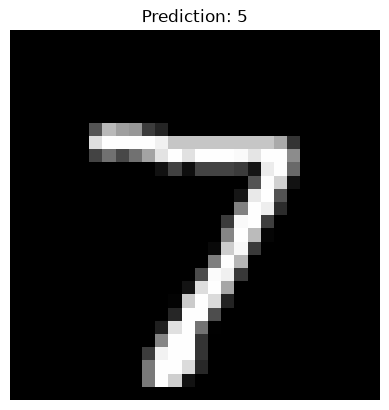

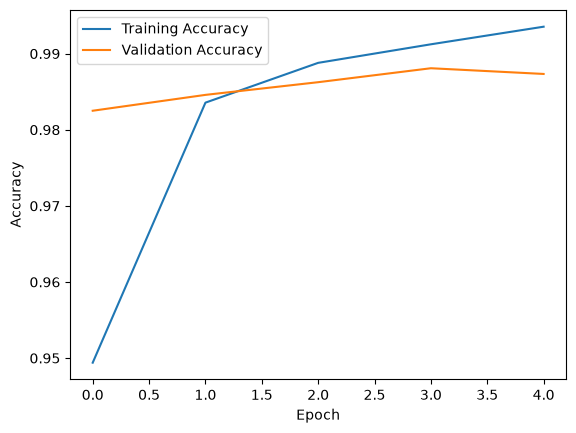

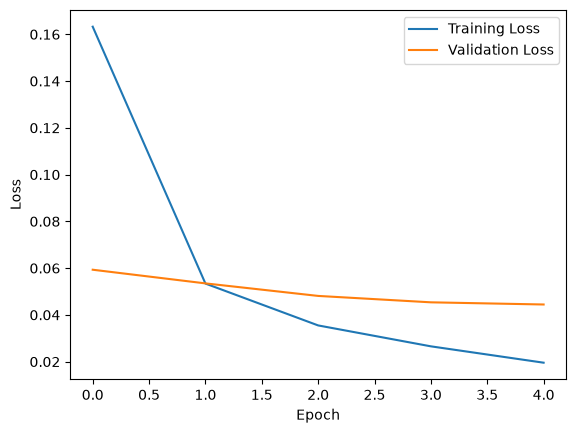

In [9]:
#now to predict the output of a single image, we will use the model.predict() function. We will also visualize the image using matplotlib

predictions = model.predict(x_test)

plt.imshow(x_test[0].reshape(28,28), cmap="gray")
plt.title(f"Prediction: {np.argmax(predictions[0])}")
plt.axis("off")
plt.show()

#accuracy graph
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#loss graph
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()